# CrashRadar — Early Warning Sistem Saham IDX

Sistem deteksi dini saham yang berisiko crash (turun >10% dalam 5 hari ke depan) menggunakan **XGBoost + SHAP**.

In [1]:
# Install all required dependencies
# joblib: model serialization for kernel-restart recovery
import sys
!{sys.executable} -m pip install -q yfinance xgboost shap scikit-learn matplotlib seaborn joblib pyarrow
!{sys.executable} -m pip install -q pandas-ta || echo "pandas-ta unavailable — will use manual indicator calculations"

'c:\Users\akbar\VSCode' is not recognized as an internal or external command,
operable program or batch file.


"pandas-ta unavailable - will use manual indicator calculations"


'c:\Users\akbar\VSCode' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
import os
import sys
import warnings
import joblib
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import shap
import yfinance as yf

from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

warnings.filterwarnings("ignore")

# pandas_ta is optional; fall back to manual calculations if unavailable
try:
    import pandas_ta as ta
    USE_PANDAS_TA = True
    print("pandas_ta loaded.")
except ImportError:
    USE_PANDAS_TA = False
    print("pandas_ta not found — using manual indicator calculations.")

# Plotting defaults
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})
sns.set_palette("tab10")

print(f"Environment ready — {datetime.now().strftime('%Y-%m-%d %H:%M')}")

c:\Users\akbar\VSCode Project\crashradar\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


pandas_ta loaded.
Environment ready — 2026-05-02 08:59


## Configuration

All tunable parameters and output paths are declared here.
Change `TICKER` to analyze a different IDX stock (e.g. `"BBRI.JK"`, `"TLKM.JK"`).

In [3]:
# ── Experiment parameters ──────────────────────────────────────────────────────
TICKER          = "BBCA.JK"  # Yahoo Finance ticker (append .JK for IDX stocks)
PERIOD          = "10y"      # Historical data window
CRASH_THRESHOLD = -0.10      # Forward return below this = crash event
FORWARD_DAYS    = 5          # Look-ahead window in trading days
TRAIN_RATIO     = 0.80       # Chronological train/test split ratio
RANDOM_STATE    = 42

# Canonical feature list — single source of truth used across all cells
FEATURE_NAMES = [
    "rsi_14",
    "volume_spike",
    "bb_position",
    "macd_diff",
    "return_5d",
    "atr_14",
    "price_vs_ma20",
    "high_low_range",
]

# Human-readable labels aligned with FEATURE_NAMES order
FEATURE_LABELS = [
    "RSI 14",
    "Volume Spike",
    "BB Position",
    "MACD Diff",
    "Return 5d",
    "ATR 14",
    "Price vs MA20",
    "High-Low Range",
]

# ── Output paths — anchored to repo root (one level above /notebooks) ──────────
# This keeps outputs consistent regardless of where Jupyter is launched from.
REPO_ROOT  = Path("__file__").resolve().parent.parent if Path("__file__").exists() else Path.cwd().parent
# Fallback: if cwd is already the repo root (e.g. VS Code), use cwd directly
if not (REPO_ROOT / "notebooks").exists():
    REPO_ROOT = Path.cwd()

OUT_DIR   = REPO_ROOT / "outputs"
FIG_DIR   = OUT_DIR / "figures"
MODEL_DIR = OUT_DIR / "models"
DATA_DIR  = OUT_DIR / "data"

for d in [FIG_DIR, MODEL_DIR, DATA_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Derived artifact paths
MODEL_PATH    = MODEL_DIR / f"crashradar_{TICKER.replace('.', '_')}.json"
JOBLIB_PATH   = MODEL_DIR / f"crashradar_{TICKER.replace('.', '_')}.pkl"
FEATURES_PATH = DATA_DIR  / f"features_{TICKER.replace('.', '_')}.parquet"

print(f"Ticker     : {TICKER}")
print(f"Period     : {PERIOD}")
print(f"Threshold  : {CRASH_THRESHOLD*100:.0f}% in {FORWARD_DAYS} trading days")
print(f"Repo root  : {REPO_ROOT}")
print(f"Output dir : {OUT_DIR}")

Ticker     : BBCA.JK
Period     : 10y
Threshold  : -10% in 5 trading days
Repo root  : c:\Users\akbar\VSCode Project\crashradar
Output dir : c:\Users\akbar\VSCode Project\crashradar\outputs


## Step 1 — Data Ingestion

Pull adjusted OHLCV data from Yahoo Finance.
yfinance >= 0.2 returns a MultiIndex column structure; we flatten it to a simple lowercase index.

In [4]:
print(f"Fetching {TICKER} ({PERIOD}) from Yahoo Finance...")
raw = yf.download(TICKER, period=PERIOD, auto_adjust=True, progress=False)

# Flatten MultiIndex columns produced by yfinance >= 0.2
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = [col[0].lower() for col in raw.columns]
else:
    raw.columns = [c.lower() for c in raw.columns]

# Drop rows where essential OHLCV fields are missing
df = raw.dropna(subset=["open", "high", "low", "close", "volume"]).copy()
df.index = pd.to_datetime(df.index)

print(f"Loaded  : {len(df):,} trading days")
print(f"Range   : {df.index[0].date()} to {df.index[-1].date()}")
print(f"Columns : {list(df.columns)}")
df.tail(3)

Fetching BBCA.JK (10y) from Yahoo Finance...
Loaded  : 2,460 trading days
Range   : 2016-05-02 to 2026-04-30
Columns : ['close', 'high', 'low', 'open', 'volume']


,close,high,low,open,volume
Date,,,,,
2026-04-28,6000.0,6075.0,5950.0,6025.0,174091200
2026-04-29,5975.0,6050.0,5950.0,6000.0,176050900
2026-04-30,5850.0,5975.0,5800.0,5950.0,303405400


## Step 2 — Crash Label Construction

For each day **T**, we look at the *minimum* close price over the next `FORWARD_DAYS` trading days.
If that minimum represents a drawdown exceeding `CRASH_THRESHOLD` relative to T's close, the day is labeled **1 (Crash Warning)**.

Using the minimum (worst case) rather than the end-of-window price makes the label sensitive to intraperiod crashes that later partially recover.

In [5]:
# Minimum close over the FORWARD_DAYS window starting from T+1
# shift(-1) moves the window start to T+1; .min() takes the worst close in [T+1, T+N]
future_min = (
    df["close"]
    .shift(-1)
    .rolling(window=FORWARD_DAYS, min_periods=FORWARD_DAYS)
    .min()
    .shift(-(FORWARD_DAYS - 1))
)

df["future_min_close"] = future_min
df["forward_return"]   = (df["future_min_close"] - df["close"]) / df["close"]
df["label"]            = (df["forward_return"] < CRASH_THRESHOLD).astype(int)

# Drop tail rows that have no valid forward window
df = df.dropna(subset=["future_min_close"]).copy()

n_total = len(df)
n_crash = df["label"].sum()
n_safe  = n_total - n_crash

print(f"Total rows       : {n_total:,}")
print(f"Crash events (1) : {n_crash:,}  ({n_crash/n_total*100:.1f}%)")
print(f"Safe days    (0) : {n_safe:,}  ({n_safe/n_total*100:.1f}%)")
print(f"Imbalance ratio  : 1:{n_safe // n_crash}")

Total rows       : 2,455
Crash events (1) : 15  (0.6%)
Safe days    (0) : 2,440  (99.4%)
Imbalance ratio  : 1:162


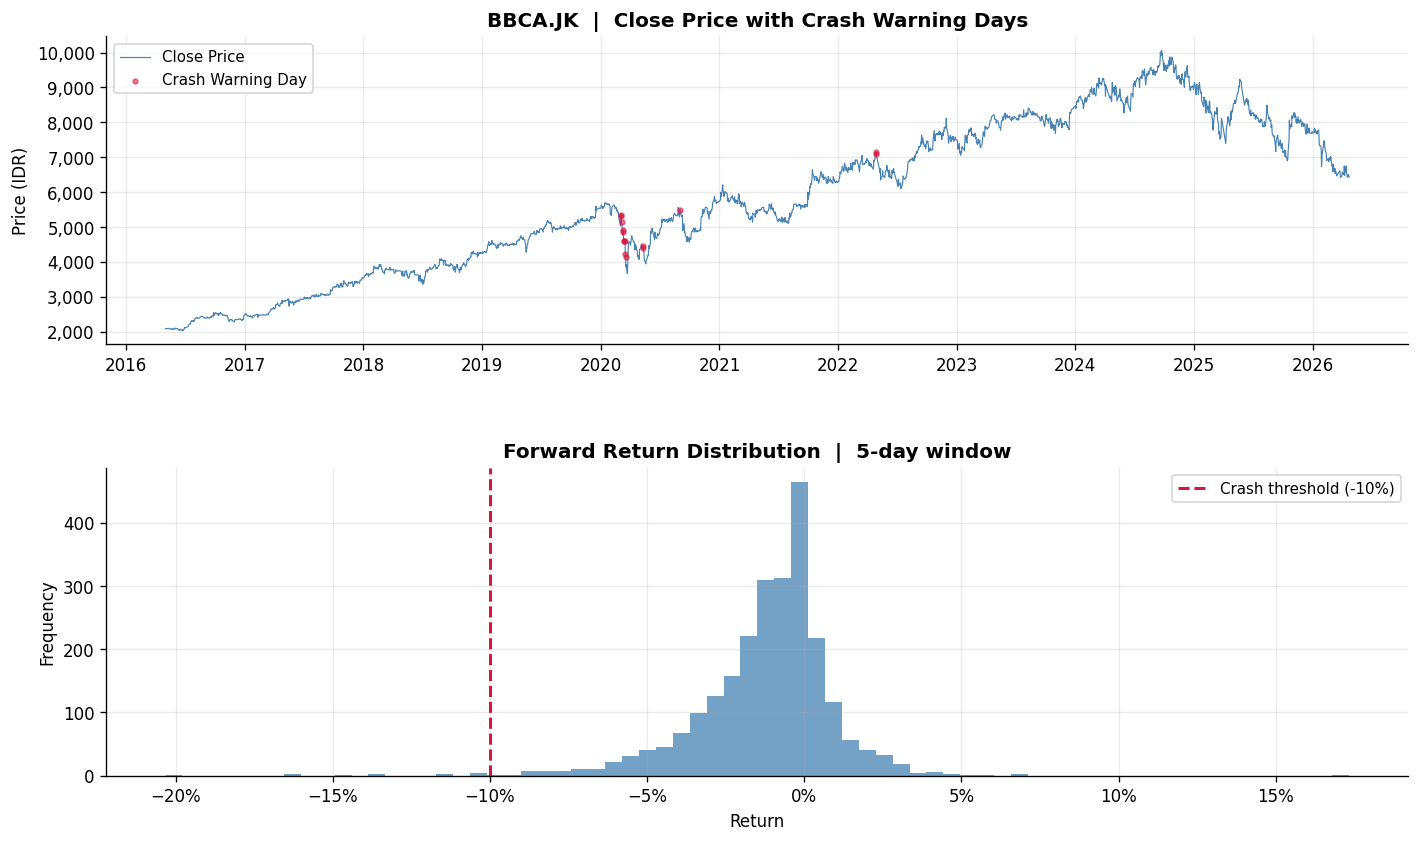

Saved: c:\Users\akbar\VSCode Project\crashradar\outputs\figures\01_crash_labels.png


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={"hspace": 0.4})

# Panel 1: price series with crash warning days overlaid
ax = axes[0]
ax.plot(df.index, df["close"], color="steelblue", linewidth=0.7, label="Close Price")
crash_idx = df[df["label"] == 1].index
ax.scatter(crash_idx, df.loc[crash_idx, "close"],
           color="crimson", s=8, alpha=0.55, zorder=5, label="Crash Warning Day")
ax.set_title(f"{TICKER}  |  Close Price with Crash Warning Days", fontsize=12, fontweight="bold")
ax.set_ylabel("Price (IDR)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(fontsize=9)

# Panel 2: forward return distribution with threshold marker
ax = axes[1]
ax.hist(df["forward_return"], bins=70, color="steelblue", alpha=0.75, edgecolor="none")
ax.axvline(CRASH_THRESHOLD, color="crimson", linestyle="--", linewidth=1.8,
           label=f"Crash threshold ({CRASH_THRESHOLD*100:.0f}%)")
ax.set_title(f"Forward Return Distribution  |  {FORWARD_DAYS}-day window", fontsize=12, fontweight="bold")
ax.set_xlabel("Return")
ax.set_ylabel("Frequency")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.legend(fontsize=9)

fig.savefig(FIG_DIR / "01_crash_labels.png", bbox_inches="tight")
plt.show()
print(f"Saved: {FIG_DIR / '01_crash_labels.png'}")

## Step 3 — Feature Engineering

All features are derived from OHLCV data alone — no external feeds required.

| Feature | Description |
|---|---|
| `rsi_14` | Relative Strength Index (14-period) — momentum/overbought signal |
| `volume_spike` | Today's volume divided by 20-day average — unusual activity detector |
| `bb_position` | Price position within Bollinger Bands — 0=lower band, 1=upper band |
| `macd_diff` | MACD histogram (12/26 EMA diff minus 9-period signal) — trend shift |
| `return_5d` | 5-day lagged price return — recent momentum |
| `atr_14` | ATR normalized by close — volatility regime indicator |
| `price_vs_ma20` | Distance from 20-day MA as pct — mean-reversion signal |
| `high_low_range` | Daily range normalized by close — intraday volatility |

In [7]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """Compute all technical indicators and append them to a copy of df."""
    out   = df.copy()
    close = out["close"]

    # RSI-14: use pandas_ta when available for speed; manual fallback otherwise
    if USE_PANDAS_TA:
        rsi_series = ta.rsi(close, length=14)
        out["rsi_14"] = rsi_series.squeeze() if hasattr(rsi_series, "squeeze") else rsi_series
    else:
        delta        = close.diff()
        gain         = delta.clip(lower=0).rolling(14).mean()
        loss         = (-delta.clip(upper=0)).rolling(14).mean()
        out["rsi_14"] = 100 - (100 / (1 + gain / loss.replace(0, np.nan)))

    # Volume spike ratio relative to 20-day rolling mean
    vol_ma20            = out["volume"].rolling(20).mean()
    out["volume_spike"] = out["volume"] / vol_ma20

    # Bollinger Bands (20, 2-sigma) — normalised price position [0, 1]
    bb_mid              = close.rolling(20).mean()
    bb_std              = close.rolling(20).std(ddof=0)
    bb_upper            = bb_mid + 2 * bb_std
    bb_lower            = bb_mid - 2 * bb_std
    out["bb_position"]  = (close - bb_lower) / (bb_upper - bb_lower + 1e-10)

    # MACD histogram: (EMA12 - EMA26) minus its 9-period signal line
    ema12              = close.ewm(span=12, adjust=False).mean()
    ema26              = close.ewm(span=26, adjust=False).mean()
    macd               = ema12 - ema26
    out["macd_diff"]   = macd - macd.ewm(span=9, adjust=False).mean()

    # 5-day lagged return
    out["return_5d"]   = close.pct_change(5)

    # Normalised ATR-14 (True Range average / close) — avoids price-scale dependency
    tr = pd.concat([
        out["high"] - out["low"],
        (out["high"] - close.shift(1)).abs(),
        (out["low"]  - close.shift(1)).abs(),
    ], axis=1).max(axis=1)
    out["atr_14"]         = tr.rolling(14).mean() / close

    # Price deviation from 20-day MA
    out["price_vs_ma20"]  = (close - bb_mid) / bb_mid

    # Normalised daily high-low range
    out["high_low_range"] = (out["high"] - out["low"]) / close

    return out


df       = build_features(df)
df_clean = df.dropna(subset=FEATURE_NAMES + ["label"]).copy()

print(f"Rows before cleaning : {len(df):,}")
print(f"Rows after  cleaning : {len(df_clean):,}  ({len(df)-len(df_clean)} dropped)")
print(f"Crash rate in clean  : {df_clean['label'].mean()*100:.2f}%")
df_clean[FEATURE_NAMES].describe().round(4)

Rows before cleaning : 2,455
Rows after  cleaning : 2,436  (19 dropped)
Crash rate in clean  : 0.62%


,rsi_14,volume_spike,bb_position,macd_diff,return_5d,atr_14,price_vs_ma20,high_low_range
count,2436.0000,2436.0000,2436.0000,2436.0000,2436.0000,2436.0000,2436.0000,2436.0000
mean,53.3265,1.0158,0.5563,-0.1200,0.0028,0.0195,0.0047,0.0182
std,10.8002,0.5765,0.3258,25.3153,0.0302,0.0081,0.0311,0.0128
min,15.1232,0.0000,-0.3935,-119.1720,-0.2032,0.0072,-0.2308,0.0000
25%,45.9251,0.6902,0.2974,-12.6591,-0.0118,0.0147,-0.0119,0.0110
50%,53.3102,0.9102,0.5786,-1.3164,0.0017,0.0183,0.0044,0.0154
75%,60.7852,1.2273,0.8084,10.2981,0.0172,0.0219,0.0216,0.0221
max,84.7123,6.8092,1.5089,126.3155,0.2472,0.0846,0.1308,0.2239


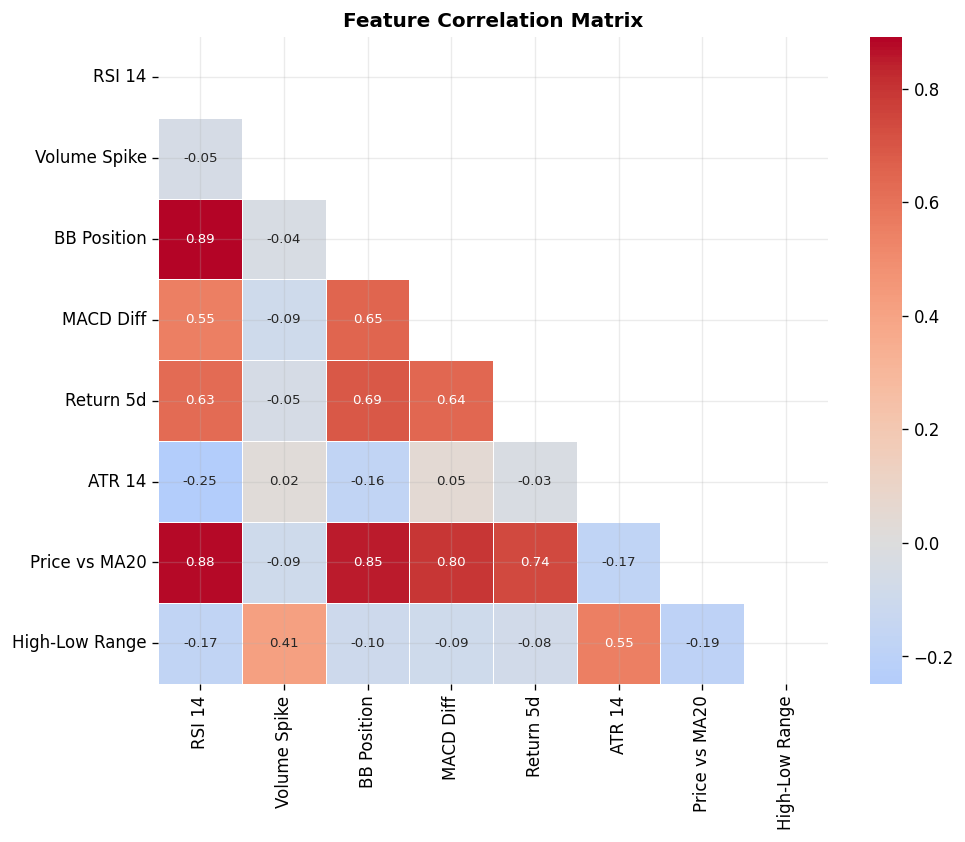

Saved: c:\Users\akbar\VSCode Project\crashradar\outputs\figures\02_feature_correlation.png


In [8]:
# Feature correlation heatmap — helps spot multicollinearity before training
fig, ax = plt.subplots(figsize=(9, 7))
corr     = df_clean[FEATURE_NAMES].rename(columns=dict(zip(FEATURE_NAMES, FEATURE_LABELS))).corr()
mask     = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, linewidths=0.4, ax=ax, annot_kws={"size": 8},
)
ax.set_title("Feature Correlation Matrix", fontsize=12, fontweight="bold")
fig.savefig(FIG_DIR / "02_feature_correlation.png", bbox_inches="tight")
plt.show()
print(f"Saved: {FIG_DIR / '02_feature_correlation.png'}")

## Step 4 — Train / Test Split and Model Training

**No random shuffling.** Time series data must be split chronologically to prevent lookahead bias.
The first 80% of observations form the training set; the remaining 20% simulate out-of-sample deployment.

`scale_pos_weight` compensates for the class imbalance by assigning higher loss weight to the minority (crash) class.

In [9]:
X = df_clean[FEATURE_NAMES]
y = df_clean["label"]

# Chronological split — no shuffling to prevent lookahead bias
split_idx           = int(len(X) * TRAIN_RATIO)
X_train, X_test     = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test     = y.iloc[:split_idx], y.iloc[split_idx:]

# Class imbalance weight: ratio of negatives to positives in training set
neg_count           = (y_train == 0).sum()
pos_count           = (y_train == 1).sum()
scale_pos_weight    = neg_count / pos_count

print(f"Train  : {len(X_train):,} rows  ({TRAIN_RATIO*100:.0f}%)  |  crash rate: {y_train.mean()*100:.1f}%")
print(f"Test   : {len(X_test):,} rows  ({(1-TRAIN_RATIO)*100:.0f}%)  |  crash rate: {y_test.mean()*100:.1f}%")
print(f"scale_pos_weight : {scale_pos_weight:.2f}")

# XGBoost — conservative depth and learning rate to limit overfitting
model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    early_stopping_rounds=30,
    random_state=RANDOM_STATE,
    verbosity=0,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
)

print(f"\nTraining complete. Best iteration: {model.best_iteration}")

# Persist model in two formats:
# .json — XGBoost native (version-portable, human-readable)
# .pkl  — joblib dump (fast Python reload, includes sklearn API wrapper)
model.save_model(str(MODEL_PATH))
joblib.dump(model, JOBLIB_PATH)
print(f"Model saved  : {MODEL_PATH}")
print(f"Model saved  : {JOBLIB_PATH}")

# Persist clean feature dataset for offline reload
df_clean.to_parquet(FEATURES_PATH)
print(f"Features saved : {FEATURES_PATH}")

Train  : 1,948 rows  (80%)  |  crash rate: 0.8%
Test   : 488 rows  (20%)  |  crash rate: 0.0%
scale_pos_weight : 128.87

Training complete. Best iteration: 297
Model saved  : c:\Users\akbar\VSCode Project\crashradar\outputs\models\crashradar_BBCA_JK.json
Model saved  : c:\Users\akbar\VSCode Project\crashradar\outputs\models\crashradar_BBCA_JK.pkl
Features saved : c:\Users\akbar\VSCode Project\crashradar\outputs\data\features_BBCA_JK.parquet


## Kernel Restart Recovery

If the kernel restarts, run **this cell only** to reload the saved model and features without
re-downloading data or re-training. Then continue from Step 5 onwards.

In [10]:
import os, warnings, joblib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import shap
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, RocCurveDisplay, PrecisionRecallDisplay,
)
warnings.filterwarnings("ignore")

# Re-declare constants — must match the Config cell above
TICKER          = "BBCA.JK"
CRASH_THRESHOLD = -0.10
FORWARD_DAYS    = 5
TRAIN_RATIO     = 0.80
RANDOM_STATE    = 42

FEATURE_NAMES = [
    "rsi_14", "volume_spike", "bb_position", "macd_diff",
    "return_5d", "atr_14", "price_vs_ma20", "high_low_range",
]
FEATURE_LABELS = [
    "RSI 14", "Volume Spike", "BB Position", "MACD Diff",
    "Return 5d", "ATR 14", "Price vs MA20", "High-Low Range",
]

# Resolve repo root from notebook location
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUT_DIR   = REPO_ROOT / "outputs"
FIG_DIR   = OUT_DIR / "figures"
MODEL_DIR = OUT_DIR / "models"
DATA_DIR  = OUT_DIR / "data"

JOBLIB_PATH   = MODEL_DIR / f"crashradar_{TICKER.replace('.', '_')}.pkl"
FEATURES_PATH = DATA_DIR  / f"features_{TICKER.replace('.', '_')}.parquet"

# Load artifacts from disk
model    = joblib.load(JOBLIB_PATH)
df_clean = pd.read_parquet(FEATURES_PATH)

# Reconstruct train/test splits
X               = df_clean[FEATURE_NAMES]
y               = df_clean["label"]
split_idx       = int(len(X) * TRAIN_RATIO)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})
sns.set_palette("tab10")

print("Recovery complete.")
print(f"Model    : {JOBLIB_PATH}")
print(f"Rows     : {len(df_clean):,}  (train={len(X_train):,}, test={len(X_test):,})")

Recovery complete.
Model    : c:\Users\akbar\VSCode Project\crashradar\outputs\models\crashradar_BBCA_JK.pkl
Rows     : 2,436  (train=1,948, test=488)


## Step 5 — Model Evaluation

Two curves are reported alongside the confusion matrix:
- **ROC-AUC**: overall discrimination power across all thresholds.
- **PR-AUC (Average Precision)**: more informative than ROC-AUC on imbalanced datasets — penalises false positives more heavily.

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        AMAN      1.000     0.982     0.991       488
       CRASH      0.000     0.000     0.000         0

    accuracy                          0.982       488
   macro avg      0.500     0.491     0.495       488
weighted avg      1.000     0.982     0.991       488

ROC-AUC           : nan
PR-AUC (Avg Prec) : 0.0000


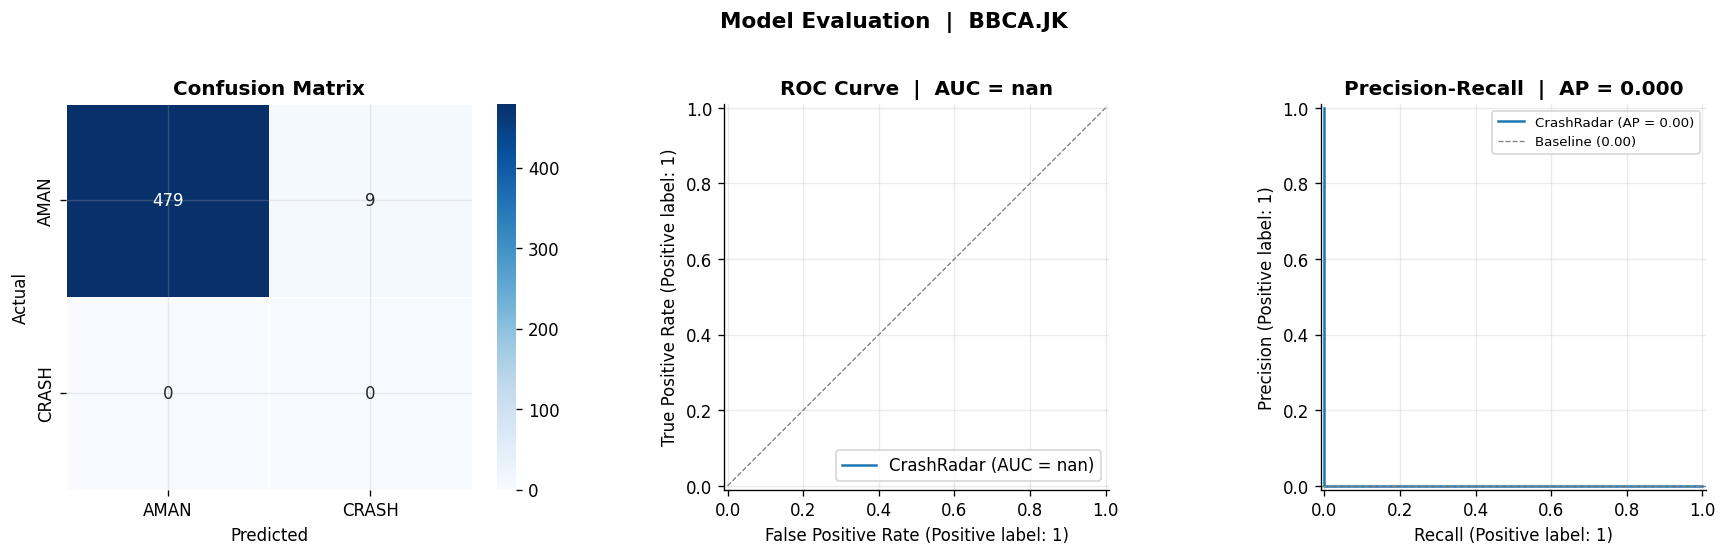

Saved: c:\Users\akbar\VSCode Project\crashradar\outputs\figures\03_model_evaluation.png


In [11]:
y_pred  = model.predict(X_test)
y_prob  = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)
pr_auc  = average_precision_score(y_test, y_prob)

print("CLASSIFICATION REPORT")
print("=" * 54)
print(classification_report(y_test, y_pred, target_names=["AMAN", "CRASH"], digits=3))
print(f"ROC-AUC           : {roc_auc:.4f}")
print(f"PR-AUC (Avg Prec) : {pr_auc:.4f}")

# Three-panel evaluation figure
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
    xticklabels=["AMAN", "CRASH"], yticklabels=["AMAN", "CRASH"],
    linewidths=0.5,
)
axes[0].set_title("Confusion Matrix", fontweight="bold")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1], name="CrashRadar")
axes[1].set_title(f"ROC Curve  |  AUC = {roc_auc:.3f}", fontweight="bold")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="grey", linewidth=0.8)

# Precision-Recall curve
PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[2], name="CrashRadar")
axes[2].set_title(f"Precision-Recall  |  AP = {pr_auc:.3f}", fontweight="bold")
baseline = y_test.mean()
axes[2].axhline(baseline, linestyle="--", color="grey", linewidth=0.8, label=f"Baseline ({baseline:.2f})")
axes[2].legend(fontsize=8)

fig.suptitle(f"Model Evaluation  |  {TICKER}", fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "03_model_evaluation.png", bbox_inches="tight")
plt.show()
print(f"Saved: {FIG_DIR / '03_model_evaluation.png'}")

## Step 6 — SHAP Explainability

SHAP (SHapley Additive exPlanations) decomposes each prediction into per-feature contributions
based on cooperative game theory. `TreeExplainer` computes exact SHAP values for tree-based
models in polynomial time.

- **Bar plot**: mean absolute SHAP — global feature importance.
- **Beeswarm plot**: full SHAP distribution — direction and magnitude per observation.

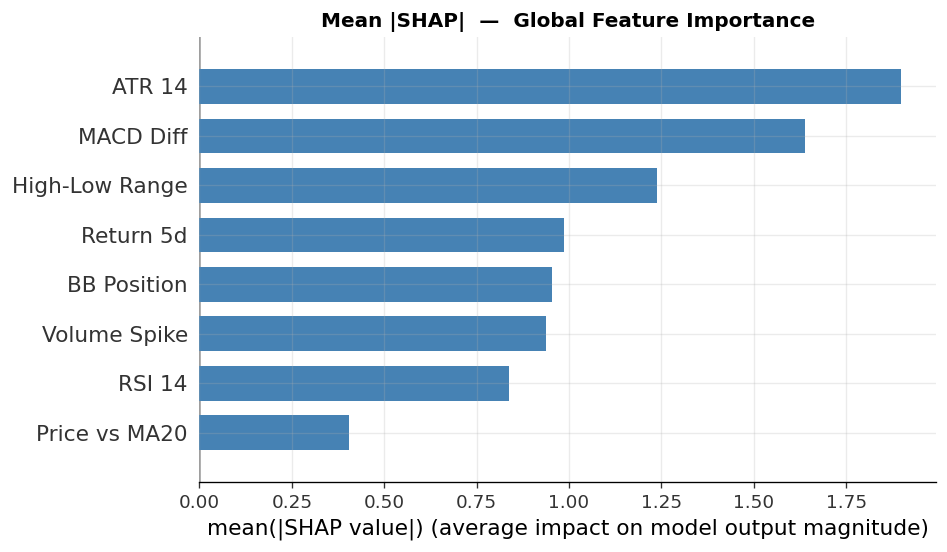

Saved: c:\Users\akbar\VSCode Project\crashradar\outputs\figures\04_shap_importance.png


In [12]:
explainer        = shap.TreeExplainer(model)
shap_values      = explainer.shap_values(X_test)
X_test_labeled   = X_test.rename(columns=dict(zip(FEATURE_NAMES, FEATURE_LABELS)))

# Bar plot — global feature importance by mean absolute SHAP
fig, ax = plt.subplots(figsize=(9, 4))
shap.summary_plot(
    shap_values, X_test_labeled,
    plot_type="bar", show=False, color="steelblue",
)
plt.gca().set_title("Mean |SHAP|  —  Global Feature Importance", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_shap_importance.png", bbox_inches="tight")
plt.show()
print(f"Saved: {FIG_DIR / '04_shap_importance.png'}")

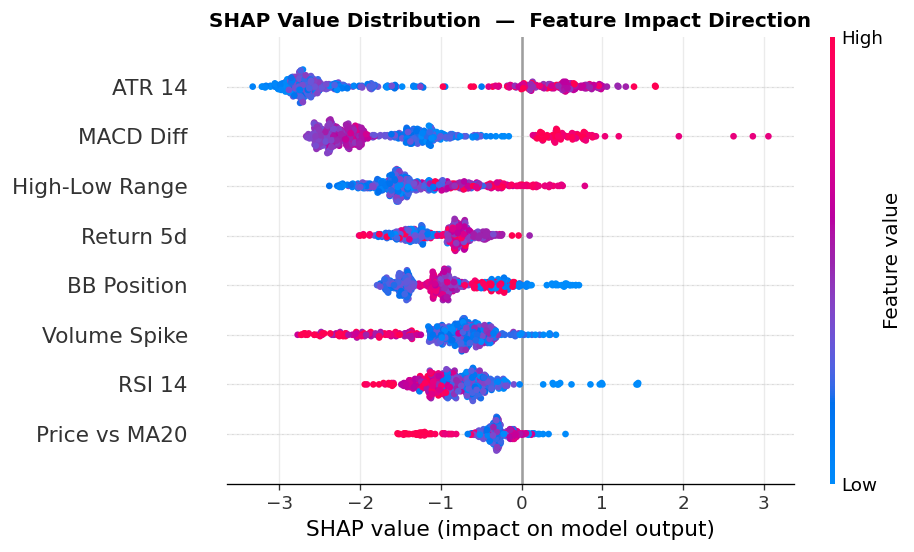

Saved: c:\Users\akbar\VSCode Project\crashradar\outputs\figures\05_shap_beeswarm.png


In [13]:
# Beeswarm plot — per-observation SHAP values (direction + magnitude)
fig, ax = plt.subplots(figsize=(9, 5))
shap.summary_plot(shap_values, X_test_labeled, show=False)
plt.gca().set_title("SHAP Value Distribution  —  Feature Impact Direction", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_shap_beeswarm.png", bbox_inches="tight")
plt.show()
print(f"Saved: {FIG_DIR / '05_shap_beeswarm.png'}")

## Step 7 — Real-time Signal: Latest Trading Day

Run inference on the most recent available data point and surface the top SHAP drivers
behind the prediction.

In [14]:
latest_row   = X.iloc[[-1]]   # Keep 2-D shape for predict_proba
latest_date  = df_clean.index[-1]
latest_prob  = model.predict_proba(latest_row)[0][1]

# Signal thresholds — tunable per risk appetite
if latest_prob >= 0.70:
    signal      = "BAHAYA"
    signal_tag  = "[HIGH RISK]"
    signal_desc = "High crash risk detected within the next 5 trading days."
elif latest_prob >= 0.40:
    signal      = "WASPADA"
    signal_tag  = "[CAUTION]"
    signal_desc = "Elevated sell pressure — monitor closely."
else:
    signal      = "AMAN"
    signal_tag  = "[SAFE]"
    signal_desc = "No crash signal detected."

print("=" * 54)
print(f"  CRASHRADAR SIGNAL  |  {TICKER}")
print(f"  Date              : {latest_date.date()}")
print("=" * 54)
print(f"  {signal_tag} {signal}")
print(f"  Crash probability : {latest_prob*100:.1f}%")
print(f"  Status            : {signal_desc}")
print("=" * 54)

# SHAP breakdown for this single prediction
shap_single = explainer.shap_values(latest_row)[0]

shap_breakdown = (
    pd.DataFrame({
        "Feature"     : FEATURE_LABELS,
        "Value"       : latest_row.values[0],
        "SHAP Impact" : shap_single,
    })
    .assign(**{"Abs": lambda d: d["SHAP Impact"].abs()})
    .sort_values("Abs", ascending=False)
    .drop(columns="Abs")
    .reset_index(drop=True)
)

print("\nTop 5 prediction drivers:")
print(shap_breakdown.head(5).to_string(index=False, float_format="{:.4f}".format))

  CRASHRADAR SIGNAL  |  BBCA.JK
  Date              : 2026-04-23
  [SAFE] AMAN
  Crash probability : 0.6%
  Status            : No crash signal detected.

Top 5 prediction drivers:
       Feature   Value  SHAP Impact
     MACD Diff  2.7809      -2.1060
High-Low Range  0.0195      -1.7694
   BB Position  0.2377      -1.6369
  Volume Spike  0.7167      -0.8586
        RSI 14 43.3103      -0.6453


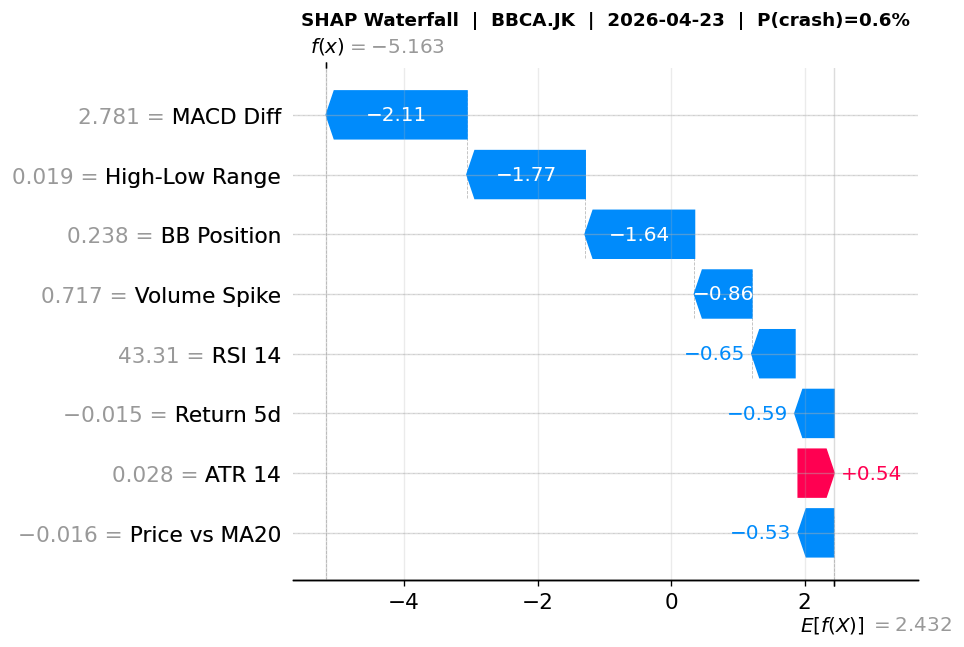

Saved: c:\Users\akbar\VSCode Project\crashradar\outputs\figures\06_shap_waterfall_latest.png


In [15]:
# Waterfall plot — SHAP force decomposition for the latest prediction
shap_exp = shap.Explanation(
    values        = shap_single,
    base_values   = explainer.expected_value,
    data          = latest_row.values[0],
    feature_names = FEATURE_LABELS,
)

fig, ax = plt.subplots(figsize=(9, 5))
shap.waterfall_plot(shap_exp, show=False)
plt.gca().set_title(
    f"SHAP Waterfall  |  {TICKER}  |  {latest_date.date()}  |  P(crash)={latest_prob*100:.1f}%",
    fontsize=11, fontweight="bold",
)
plt.tight_layout()
plt.savefig(FIG_DIR / "06_shap_waterfall_latest.png", bbox_inches="tight")
plt.show()
print(f"Saved: {FIG_DIR / '06_shap_waterfall_latest.png'}")

## Conclusion

CrashRadar is a data-driven early warning system — not a price predictor.

### What was built

| Component | Details |
|---|---|
| **Data pipeline** | Automated OHLCV ingestion via yfinance |
| **Labeling** | Forward min-return crash events (horizon = 5 days) |
| **Features** | 8 technical indicators derived purely from OHLCV |
| **Model** | XGBoost with class-imbalance weighting and early stopping |
| **Evaluation** | ROC-AUC + PR-AUC + Confusion Matrix |
| **Explainability** | SHAP TreeExplainer (global bar, beeswarm, per-prediction waterfall) |
| **Persistence** | Model saved as `.json` (native) and `.pkl` (joblib) |
| **Outputs** | Figures auto-saved to `outputs/figures/` |

### Potential next steps

- Walk-forward cross-validation for more robust out-of-sample estimates
- Extended feature set with macro indicators (USD/IDR, commodity prices, foreign flow)
- Threshold calibration via Platt scaling or isotonic regression
- Backtesting a trading strategy driven by signal outputs